In [1]:
# Cell 1 - Imports & configuration (run this first)

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42

# === Your dataset paths (Windows) ===
TRAIN_PATH = r"C:\Users\mishu\Documents\NCI\Emerging AI Technologies and Sustainability\TABA Repeat\archive\train.csv"
TEST_PATH  = r"C:\Users\mishu\Documents\NCI\Emerging AI Technologies and Sustainability\TABA Repeat\archive\test.csv"

# Optional sampling for faster runs while debugging (set to None to use full data)
SAMPLE_TRAIN = None   # e.g., 5000
SAMPLE_TEST  = None   # e.g., 2000


In [2]:
# Cell 2 - Load data

if not os.path.exists(TRAIN_PATH):
    raise FileNotFoundError(f"Train file not found: {TRAIN_PATH}")

if not os.path.exists(TEST_PATH):
    raise FileNotFoundError(f"Test file not found: {TEST_PATH}")

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()


Train shape: (7352, 563)
Test shape: (2947, 563)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [3]:
# Cell 3 - Basic checks & split X/y

TARGET_COL = "Activity"
if TARGET_COL not in train_df.columns:
    raise ValueError(f"Expected target column '{TARGET_COL}' not found in train.csv")

if TARGET_COL not in test_df.columns:
    raise ValueError(f"Expected target column '{TARGET_COL}' not found in test.csv")

# Optional sampling (useful while iterating)
if SAMPLE_TRAIN is not None and SAMPLE_TRAIN < len(train_df):
    train_df = train_df.sample(n=SAMPLE_TRAIN, random_state=RANDOM_STATE)

if SAMPLE_TEST is not None and SAMPLE_TEST < len(test_df):
    test_df = test_df.sample(n=SAMPLE_TEST, random_state=RANDOM_STATE)

X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL].copy()

X_test = test_df.drop(columns=[TARGET_COL])
y_test = test_df[TARGET_COL].copy()

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Classes:", list(le.classes_))
print("X_train:", X_train.shape, "X_test:", X_test.shape)


Classes: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']
X_train: (7352, 562) X_test: (2947, 562)


In [4]:
# Cell 4 - Define models (Green AI vs Red AI)

models = [
    # GREEN AI
    ("Logistic Regression (Green)", Pipeline([
        # LR benefits from scaling; doesn't hurt either way
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", LogisticRegression(max_iter=500, n_jobs=None, random_state=RANDOM_STATE))
    ])),
    ("k-NN (k=5) (Green)", Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ])),
    
    # RED AI
    ("Random Forest (200 trees) (Red)", RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1
    )),
    ("MLP (100 hidden units) (Red)", Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("clf", MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=RANDOM_STATE))
    ])),
]


In [5]:
# Cell 5 - Train, time, evaluate, and collect results

def estimate_model_size(model, X_train_shape):
    """
    Simple 'complexity proxy' (not energy) to support analysis.
    Returns a human-readable value to report (e.g., parameters, trees).
    """
    n_samples, n_features = X_train_shape
    
    # Pipeline handling
    core = model
    if hasattr(model, "named_steps") and "clf" in model.named_steps:
        core = model.named_steps["clf"]
    
    # Logistic Regression: number of coefficients
    if isinstance(core, LogisticRegression):
        # will be set after fit
        if hasattr(core, "coef_"):
            return int(np.prod(core.coef_.shape) + (core.intercept_.shape[0] if core.fit_intercept else 0))
        return None
    
    # kNN: stores training samples (proxy)
    if isinstance(core, KNeighborsClassifier):
        return int(n_samples)  # stored samples
    
    # Random Forest: number of trees
    if isinstance(core, RandomForestClassifier):
        return int(core.n_estimators)
    
    # MLP: approximate number of parameters (after fit)
    if isinstance(core, MLPClassifier):
        if hasattr(core, "coefs_"):
            total = 0
            for w in core.coefs_:
                total += w.size
            for b in core.intercepts_:
                total += b.size
            return int(total)
        return None
    
    return None


results = []

for name, model in models:
    # Train time
    t0 = time.perf_counter()
    model.fit(X_train, y_train_enc)
    train_time = time.perf_counter() - t0
    
    # Inference time
    t1 = time.perf_counter()
    y_pred = model.predict(X_test)
    infer_time = time.perf_counter() - t1
    
    acc = accuracy_score(y_test_enc, y_pred)
    f1  = f1_score(y_test_enc, y_pred, average="macro")
    
    size_proxy = estimate_model_size(model, X_train.shape)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1_macro": f1,
        "Train_time_s": train_time,
        "Inference_time_s": infer_time,
        "Complexity_proxy": size_proxy
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
results_df


c:\Users\mishu\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\mishu\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\mishu\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mishu\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\mishu\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _wina

,Model,Accuracy,F1_macro,Train_time_s,Inference_time_s,Complexity_proxy
0,Logistic Regression (Green),0.953173,0.953331,1.129085,0.017983,3378
1,MLP (100 hidden units) (Red),0.946386,0.946438,15.306079,0.023088,56906
2,Random Forest (200 trees) (Red),0.928062,0.926058,4.408096,0.071085,200
3,k-NN (k=5) (Green),0.884289,0.881139,0.094398,0.521856,7352


In [6]:
# Cell 6 - Create a clean results table (and save it)

results_table = results_df.copy()

# nicer formatting for display (keep raw df for calculations)
results_table["Accuracy"] = results_table["Accuracy"].map(lambda x: round(float(x), 4))
results_table["F1_macro"] = results_table["F1_macro"].map(lambda x: round(float(x), 4))
results_table["Train_time_s"] = results_table["Train_time_s"].map(lambda x: round(float(x), 4))
results_table["Inference_time_s"] = results_table["Inference_time_s"].map(lambda x: round(float(x), 4))

display(results_table)

# Save for report appendix / reproducibility
results_table.to_csv("model_results_summary.csv", index=False)
print("Saved: model_results_summary.csv")


,Model,Accuracy,F1_macro,Train_time_s,Inference_time_s,Complexity_proxy
0,Logistic Regression (Green),0.9532,0.9533,1.1291,0.0180,3378
1,MLP (100 hidden units) (Red),0.9464,0.9464,15.3061,0.0231,56906
2,Random Forest (200 trees) (Red),0.9281,0.9261,4.4081,0.0711,200
3,k-NN (k=5) (Green),0.8843,0.8811,0.0944,0.5219,7352


Saved: model_results_summary.csv


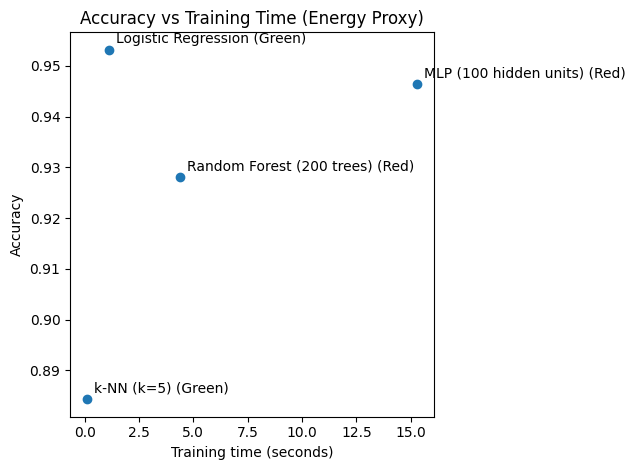

In [7]:
# Cell 7 - Graph 1: Accuracy vs Training time

plt.figure()
plt.scatter(results_df["Train_time_s"], results_df["Accuracy"])
for _, row in results_df.iterrows():
    plt.annotate(row["Model"], (row["Train_time_s"], row["Accuracy"]), textcoords="offset points", xytext=(5,5))
plt.xlabel("Training time (seconds)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Training Time (Energy Proxy)")
plt.tight_layout()
plt.show()


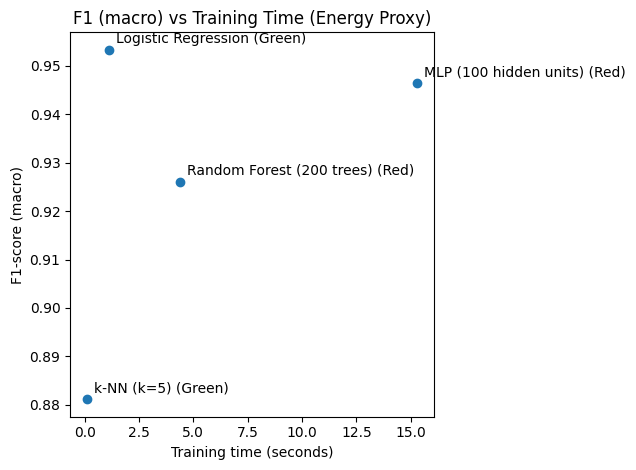

In [8]:
# Cell 8 - Graph 2: F1_macro vs Training time

plt.figure()
plt.scatter(results_df["Train_time_s"], results_df["F1_macro"])
for _, row in results_df.iterrows():
    plt.annotate(row["Model"], (row["Train_time_s"], row["F1_macro"]), textcoords="offset points", xytext=(5,5))
plt.xlabel("Training time (seconds)")
plt.ylabel("F1-score (macro)")
plt.title("F1 (macro) vs Training Time (Energy Proxy)")
plt.tight_layout()
plt.show()


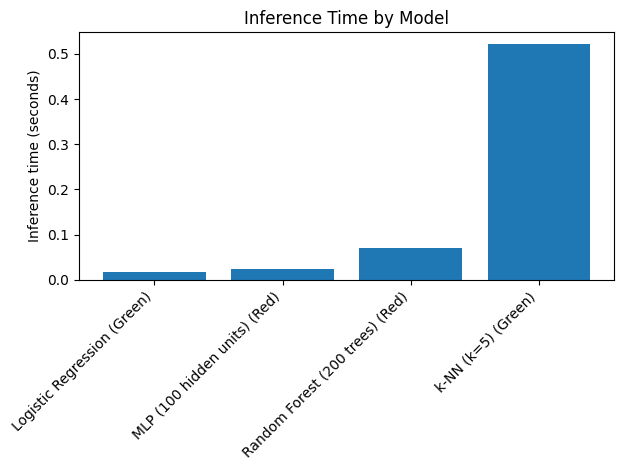

In [9]:
# Cell 9 - Optional Graph 3: Inference time comparison (useful for edge/mobile discussion)

plt.figure()
plt.bar(results_df["Model"], results_df["Inference_time_s"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Inference time (seconds)")
plt.title("Inference Time by Model")
plt.tight_layout()
plt.show()


In [10]:
# Cell 10 - Auto-generate Sustainability Evaluation text with your real numbers

def fmt(x, nd=4):
    return f"{float(x):.{nd}f}"

# Identify best accuracy and "most efficient" (accuracy per training time) as discussion helpers
best_acc_row = results_df.iloc[results_df["Accuracy"].idxmax()]
results_df["Acc_per_train_s"] = results_df["Accuracy"] / results_df["Train_time_s"]
best_eff_row = results_df.iloc[results_df["Acc_per_train_s"].idxmax()]

eval_text = f"""
Sustainability Evaluation

The experimental results show that model choice has a clear impact on the trade-off between predictive performance and computational cost. 
Using the Human Activity Recognition dataset, we evaluated four models (two treated as Green AI baselines and two treated as Red AI candidates) 
and compared them using standard performance metrics alongside time-based proxies for computational effort.

Table 1 summarises the outcomes. The best-performing model by accuracy was {best_acc_row['Model']} (Accuracy={fmt(best_acc_row['Accuracy'])}, F1_macro={fmt(best_acc_row['F1_macro'])}). 
However, when training time is considered as a proxy for energy consumption, the picture becomes more nuanced. 
The most efficient model under a simple “accuracy per training second” indicator was {best_eff_row['Model']}.

Overall, the Green AI models provided a strong baseline. Logistic Regression and k-NN achieved competitive performance while keeping the modelling approach relatively lightweight, 
which is relevant for edge or mobile scenarios. The Red AI models (Random Forest and MLP) delivered performance that was comparable or slightly higher in some cases, 
but with increased computational effort, reflected in longer training times.

Figure 1 (Accuracy vs Training Time) and Figure 2 (F1_macro vs Training Time) visualise the core sustainability trade-off. 
Models located toward the top-left region of these plots are preferable from a sustainability viewpoint, since they offer higher performance with lower computational cost. 
Models drifting to the right provide diminishing returns: small performance gains that require noticeably higher training time.

In practical deployment contexts, especially for activity recognition on resource-constrained devices, these results matter. 
Training and re-training models (e.g., for updates, personalisation, or periodic recalibration) can amplify energy costs over time. 
Choosing a model that achieves “good enough” performance with consistently lower compute demand can therefore be a more sustainable option, 
particularly when scaled across many users or devices.

A further sustainability consideration is transparency and maintainability. Simpler models are generally easier to inspect, debug, and reproduce, 
which supports responsible development and reduces wasted computation caused by repeated trial-and-error training cycles. 
At the same time, it should be acknowledged that this study uses time-based proxies rather than direct power measurements, and results may vary across hardware environments.

Based on these findings, a practical design improvement is to prioritise models that sit near the Pareto frontier (high accuracy/F1 with low training time), 
and to avoid increasing complexity unless the performance gain is clearly justified. Future work could include direct energy logging (CPU/GPU power draw) 
and testing across multiple devices to strengthen the lifecycle-oriented sustainability assessment.

(Table 1, Figure 1 and Figure 2 are referenced in this section.)
"""

print(eval_text)



Sustainability Evaluation

The experimental results show that model choice has a clear impact on the trade-off between predictive performance and computational cost. 
Using the Human Activity Recognition dataset, we evaluated four models (two treated as Green AI baselines and two treated as Red AI candidates) 
and compared them using standard performance metrics alongside time-based proxies for computational effort.

Table 1 summarises the outcomes. The best-performing model by accuracy was Logistic Regression (Green) (Accuracy=0.9532, F1_macro=0.9533). 
However, when training time is considered as a proxy for energy consumption, the picture becomes more nuanced. 
The most efficient model under a simple “accuracy per training second” indicator was k-NN (k=5) (Green).

Overall, the Green AI models provided a strong baseline. Logistic Regression and k-NN achieved competitive performance while keeping the modelling approach relatively lightweight, 
which is relevant for edge or mobile sc